In [42]:
import numpy as np
import jax
import jax.numpy as jnp
import util.functions as functions
from models.FNO import CAPE_FNO
import pybamm
import flax
import gc

In [2]:
from skopt.utils import use_named_args
from skopt.space import Real
from skopt import gp_minimize

In [3]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
# from util.plotting import create_plot_FNO_results, create_plot_voltage
from util.postprocess import filter_anode_cathode
from inference.parameter_estimation import get_jnp_U_OCP_anode, get_jnp_U_OCP_cathode

In [52]:
family = "GRF"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
split_seed = 42
test_ratio = 0.1

In [61]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
U_OCP_an = get_jnp_U_OCP_anode(parameter_name)
U_OCP_ca = get_jnp_U_OCP_cathode(parameter_name)


C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]

EPS = 1e-12
t_max = 3600

In [6]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=split_seed)  # noqa: F405

In [7]:
func_I = np.array(test_data["current"])

### Anode data ###
cn_anode = np.array(test_data["cn_anode"])
c0_anode = np.array(test_data["c0_anode"])
D_anode = np.array(test_data["Dan"])

### Cathode data ###
cn_cathode = np.array(test_data["cn_cathode"])
c0_cathode = np.array(test_data["c0_cathode"])
D_cathode = np.array(test_data["Dca"])

soc = np.array(test_data["soc"])

In [9]:
D_anode = normalise_diffusion(D_anode)
D_cathode = normalise_diffusion(D_cathode)

In [10]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
cs_max_a_norm = 1 #params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c_norm = 1 #params_bat["Maximum concentration in positive electrode [mol.m-3]"]
cs_min_a_norm = 0.0
cs_min_c_norm = 0.0

In [11]:
cn_anode, cn_cathode, mask = filter_anode_cathode(cn_anode, cn_cathode,
                                                    anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                    cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [12]:
func_I = func_I[mask]
c0_anode = c0_anode[mask]
c0_cathode = c0_cathode[mask]
D_anode = D_anode[mask]
D_cathode = D_cathode[mask]
soc = soc[mask]

In [53]:
N_test = func_I.shape[0]
rng = np.random.default_rng(split_seed)
test_idx = 0 #rng.integers(0, N_test)

In [13]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [14]:
X_anode, Y_anode = preprocess_data(func_I, c0_anode, cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_cathode, Y_cathode = preprocess_data(func_I, c0_cathode, cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [15]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
input_channels = 4 # We should automate this TODO
output_channels = 1
cape_hidden_size = 32

In [16]:
test_seed = 29
N_test = func_I.shape[0]
rng = np.random.default_rng(test_seed)
test_idx = rng.integers(0, N_test)

In [17]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, 
                 fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, 
                 hidden_channels=hidden_channels, output_channels=output_channels)

main_key = jax.random.PRNGKey(split_seed)
# Initialize parameters
dummy_D = jax.random.normal(main_key, (1,1))
params = model.init(main_key, X_anode[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_anode[:1,...], dummy_D)

In [18]:
anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_17-11-44.msgpack"
cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_17-35-54.msgpack"

params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [19]:
LOG10_D_MIN, LOG10_D_MAX = -15.0, -12.0 #Immer hier abchecken

In [20]:
R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

In [21]:
V_pred_list = []
c_an_surf_list = []
c_ca_surf_list = []

In [22]:
def calc_voltage(params_bat, c_an_surf, c_ca_surf, func_I,):
    # Calculate the anode and cathode OCPs

    j_anode   = jnp.sqrt(c_an_surf * (1.0 - c_an_surf))
    j_cathode = jnp.sqrt(c_ca_surf * (1.0 - c_ca_surf))

    xan = functions.in_arcsinh(-func_I, Ran, epsan, Lan, A)
    xca = functions.in_arcsinh(-func_I, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(c_ca_surf) - U_OCP_an(c_an_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))

    return V_pred

In [23]:
kan = Ran / (3 * epsan * Lan * A)
kca = Rca / (3 * epsca * Lca * A)
RTF = 2 * R_gas*Temp/F

In [24]:
@jax.jit
def inference_step(func_I_truth, X_anode_truth, X_cathode_truth, D_anode_candidate, D_cathode_candidate):
    cn_anode = model.apply(params_anode,X_anode_truth, D_anode_candidate)
    cn_cathode = model.apply(params_cathode,X_cathode_truth, D_cathode_candidate)

    cn_anode_reshape = remove_padding(cn_anode, padding_r = padding_r, padding_t = padding_t)
    cn_cathode_reshape = remove_padding(cn_cathode, padding_r = padding_r, padding_t = padding_t)

    cn_anode_surf = cn_anode_reshape[:, -1, :, 0].clip(EPS, 1.0 - EPS)
    cn_cathode_surf = cn_cathode_reshape[:, -1, :, 0].clip(EPS, 1.0 - EPS)

    j_anode   = jnp.sqrt(cn_anode_surf * (1.0 - cn_anode_surf))
    j_cathode = jnp.sqrt(cn_cathode_surf * (1.0 - cn_cathode_surf))

    xan = -func_I_truth * kan
    xca = -func_I_truth * kca

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - RTF * jnp.arcsinh(0.5*xan/(j_anode)) - RTF * jnp.arcsinh(0.5*xca/(j_cathode))
    return V_pred

In [25]:
# ---- design space ----------------------------------------
dimensions = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca"),
]

In [26]:
V_data = functions.post_proc_true(params_bat, func_I[test_idx], cn_anode[test_idx,-1,:], cn_cathode[test_idx,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
assert np.isfinite(V_data).all()

In [27]:
@jax.jit
def calc_rmse(V_pred, V_data):
    rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
    return rmse

@jax.jit
def calc_rel_l2(V_pred, V_data):
    rel_l2 = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2)) / jnp.sqrt(jnp.mean(V_data ** 2))
    return rel_l2

In [28]:
normalise_diffusion = jax.jit(normalise_diffusion)


In [29]:
# @use_named_args(dimensions)
# def obj_voltage(log10_Dan, log10_Dca):
#     # --- 1.  normalise the candidate diffusivities ------------
#     log10_Dan_norm = normalise_diffusion(jnp.array(log10_Dan).reshape(-1,1))
#     log10_Dca_norm = normalise_diffusion(jnp.array(log10_Dca).reshape(-1,1))
#     # --- 2.  CAPE-FNO predictions of c(r,t) ---------------
#     V_pred = inference_step(candidate_I,
#         candidate_X_anode[None,...], candidate_X_cathode[None,...],
#         log10_Dan_norm, log10_Dca_norm
#     )
#     #V_pred_list.append(V_pred)

#     # --- 4.  voltage RMSE (you can use MAE or any other scalar) -------------
#     error = calc_rel_l2(V_pred, V_data)
    
#     return float(error)

In [62]:
def make_obj_voltage(test_idx):
    """Return an obj_voltage whose `test_idx` is fixed."""
    @use_named_args(dimensions)
    def obj_voltage(log10_Dan, log10_Dca):
        # 1. normalise
        log10_Dan_norm = normalise_diffusion(
            jnp.array(log10_Dan).reshape(-1, 1)
        )
        log10_Dca_norm = normalise_diffusion(
            jnp.array(log10_Dca).reshape(-1, 1)
        )

        # 2. CAPE-FNO predictions
        V_pred = inference_step(
            func_I[test_idx],
            X_anode[test_idx][None, ...],
            X_cathode[test_idx][None, ...],
            log10_Dan_norm,
            log10_Dca_norm,
        )

        # 3. scalar error
        return float(calc_rmse(V_pred, V_data))

    return obj_voltage

In [63]:
D_anode_estimate = np.empty_like(D_anode)
D_cathode_estimate = np.empty_like(D_cathode)
V_error = np.empty_like(D_anode)

In [ ]:
for idx in range(11):
    obj_fn = make_obj_voltage(idx)     # <- idx captured here
    res = gp_minimize(
        obj_fn,
        dimensions=dimensions,
        n_calls=60,
        n_initial_points=12,
        acq_func="EI",
        random_state=0,
    )
    best_log10_Dan, best_log10_Dca = res.x
    print(f"Best log10(Dan) = {best_log10_Dan:.3f}")
    print(f"Best log10(Dca) = {best_log10_Dca:.3f}")
    D_anode_estimate[idx] = best_log10_Dan
    D_cathode_estimate[idx] = best_log10_Dca
    V_error[idx] = res.fun


Best log10(Dan) = -12.000
Best log10(Dca) = -15.000
Best log10(Dan) = -12.000
Best log10(Dca) = -12.005
Best log10(Dan) = -13.613
Best log10(Dca) = -14.931
Best log10(Dan) = -12.172
Best log10(Dca) = -13.753
Best log10(Dan) = -12.222
Best log10(Dca) = -13.608
Best log10(Dan) = -12.563
Best log10(Dca) = -13.560
Best log10(Dan) = -12.000
Best log10(Dca) = -14.922
Best log10(Dan) = -14.650
Best log10(Dca) = -14.979
Best log10(Dan) = -12.000
Best log10(Dca) = -14.794
Best log10(Dan) = -13.822
Best log10(Dca) = -12.492
Best log10(Dan) = -12.000
Best log10(Dca) = -12.000


In [ ]:
for idx in range(11):#func_I.shape[0]):

    candidate_I = func_I[idx]
    candidate_X_anode = X_anode[idx]
    candidate_X_cathode = X_cathode[idx]

    # print(candidate_I.shape)
    # print(candidate_X_anode[None,...].shape)
    # print(candidate_X_cathode.shape)

    print(idx)

    res = gp_minimize(
        obj_voltage,
        dimensions=dimensions,
        n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
        n_initial_points=12,   # random Sobol/Bach search first
        acq_func="EI",         # expected improvement
        random_state=0,
    )

    best_log10_Dan, best_log10_Dca = res.x
    print(f"Best log10(Dan) = {best_log10_Dan:.3f}")
    print(f"Best log10(Dca) = {best_log10_Dca:.3f}")
    D_anode_estimate[idx] = best_log10_Dan
    D_cathode_estimate[idx] = best_log10_Dca
    V_error[idx] = res.fun

    # print(f"Best log10(Dan) = {best_log10_Dan:.3f}")
    # print(f"Best log10(Dca) = {best_log10_Dca:.3f}")
    # print(f"Voltage-curve RMSE = {res.fun:.4e}")

(75,)
(1, 24, 85, 4)
(24, 85, 4)
0
Best log10(Dan) = -12.000
Best log10(Dca) = -15.000
(75,)
(1, 24, 85, 4)
(24, 85, 4)
1
Best log10(Dan) = -12.001
Best log10(Dca) = -12.434
(75,)
(1, 24, 85, 4)
(24, 85, 4)
2
Best log10(Dan) = -13.630
Best log10(Dca) = -14.989
(75,)
(1, 24, 85, 4)
(24, 85, 4)
3
Best log10(Dan) = -12.172
Best log10(Dca) = -13.753
(75,)
(1, 24, 85, 4)
(24, 85, 4)
4
Best log10(Dan) = -12.222
Best log10(Dca) = -13.608
(75,)
(1, 24, 85, 4)
(24, 85, 4)
5
Best log10(Dan) = -12.563
Best log10(Dca) = -13.560
(75,)
(1, 24, 85, 4)
(24, 85, 4)
6
Best log10(Dan) = -12.194
Best log10(Dca) = -14.969
(75,)
(1, 24, 85, 4)
(24, 85, 4)
7
Best log10(Dan) = -14.665
Best log10(Dca) = -13.442
(75,)
(1, 24, 85, 4)
(24, 85, 4)
8
Best log10(Dan) = -12.000
Best log10(Dca) = -14.794
(75,)
(1, 24, 85, 4)
(24, 85, 4)
9
Best log10(Dan) = -13.822
Best log10(Dca) = -12.492
(75,)
(1, 24, 85, 4)
(24, 85, 4)
10
Best log10(Dan) = -12.050
Best log10(Dca) = -12.005


In [64]:

# rng is the np.random.Generator you said you already have
def run_bo_single(test_idx, rng, dimensions, n_calls=60, n_initial_points=12):
    """
    One hermetically-sealed Bayesian-optimisation run.

    Parameters
    ----------
    test_idx : int
        Index of the voltage trace to fit.
    rng : np.random.Generator
        Shared generator; each call draws its *own* fresh seed from it.
    dimensions : list
        Search space fed to gp_minimize.
    """
    # 1️⃣  Freeze every global RNG so experiments are reproducible and independent
    seed = int(rng.integers(0, 2**32 - 1))
    np.random.seed(seed)

    # 2️⃣  Build both the objective and the optimiser *inside* this function
    obj_fn = make_obj_voltage(test_idx)
    res = gp_minimize(
        obj_fn,
        dimensions=dimensions,
        n_calls=n_calls,
        n_initial_points=n_initial_points,
        acq_func="EI",
        random_state=seed,     # lets scikit-optimize follow the same seed
    )

    best_log10_Dan, best_log10_Dca = res.x
    fun = res.fun             # store this *before* we delete res

    # 3️⃣  Clean up heavy state so the next run starts fresh
    del obj_fn, res
    gc.collect()
    return best_log10_Dan, best_log10_Dca, fun


In [65]:
for idx in range(11):
    Dan_est, Dca_est, err = run_bo_single(idx, rng, dimensions)
    D_anode_estimate[idx]   = Dan_est
    D_cathode_estimate[idx] = Dca_est
    V_error[idx]            = err
    print(f"[{idx}] RMSE = {err:.4f} | log10(Dan) = {Dan_est:.3f} | log10(Dca) = {Dca_est:.3f}")


[0] RMSE = 0.2450 | log10(Dan) = -12.001 | log10(Dca) = -14.999
[1] RMSE = 0.2183 | log10(Dan) = -12.002 | log10(Dca) = -12.104
[2] RMSE = 0.5316 | log10(Dan) = -13.636 | log10(Dca) = -14.976
[3] RMSE = 0.1736 | log10(Dan) = -12.094 | log10(Dca) = -12.802
[4] RMSE = 0.1956 | log10(Dan) = -12.006 | log10(Dca) = -12.882
[5] RMSE = 0.1992 | log10(Dan) = -12.543 | log10(Dca) = -14.997
[6] RMSE = 0.1765 | log10(Dan) = -12.001 | log10(Dca) = -14.946
[7] RMSE = 0.2128 | log10(Dan) = -14.619 | log10(Dca) = -12.019
[8] RMSE = 0.1939 | log10(Dan) = -12.004 | log10(Dca) = -14.181
[9] RMSE = 0.1924 | log10(Dan) = -12.000 | log10(Dca) = -14.018
[10] RMSE = 0.2090 | log10(Dan) = -12.001 | log10(Dca) = -12.025


In [45]:
V_data = functions.post_proc_true(params_bat, func_I, cn_anode[:,-1,:], cn_cathode[:,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)

In [46]:
V_best_cape_fno_from_cape_fno = inference_step(func_I[:10],
    X_anode[:10], X_cathode[:10],
    normalise_diffusion(D_anode_estimate[:10].reshape(-1,1)), normalise_diffusion(D_cathode_estimate[:10].reshape(-1,1))
)

In [47]:
D_anode

array([ 0.24139119,  0.84508198, -0.33003512, ...,  0.73176733,
        0.13856574, -0.28523369], shape=(1296,))

In [48]:
V_best_cape_fno_from_cape_fno.shape

(10, 75)

In [49]:
import matplotlib.pyplot as plt

In [50]:
V_data[:10].shape

(10, 75)

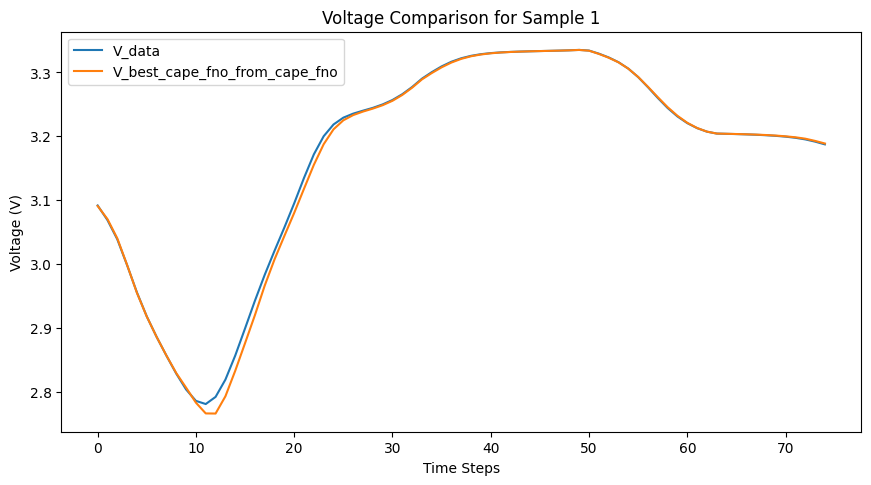

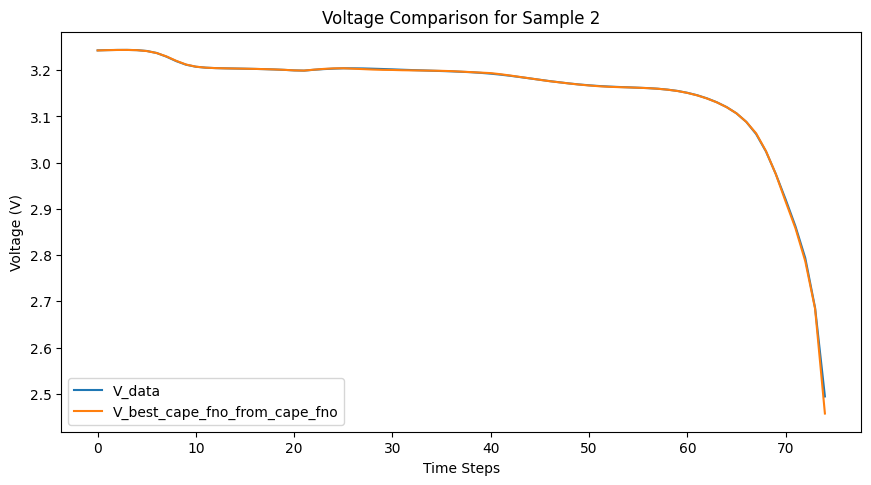

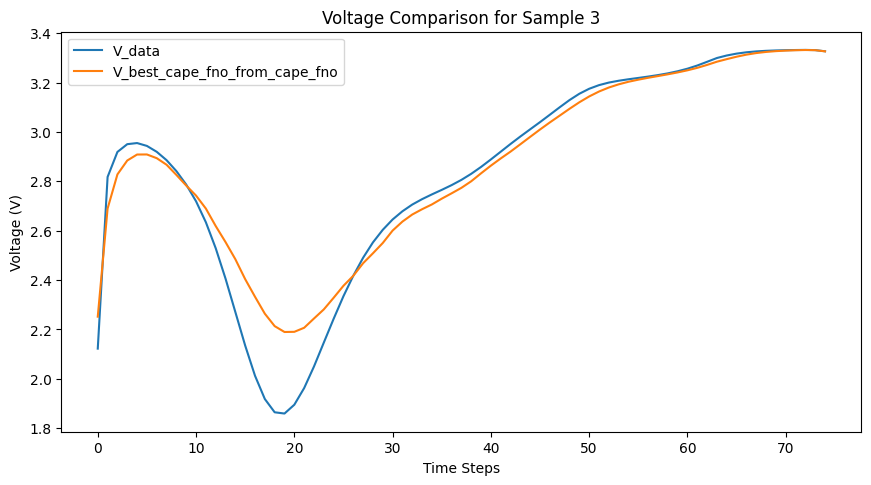

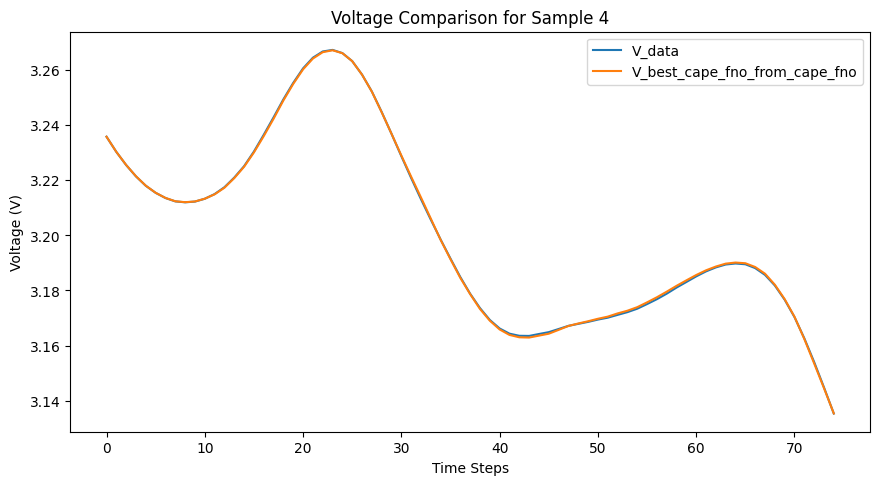

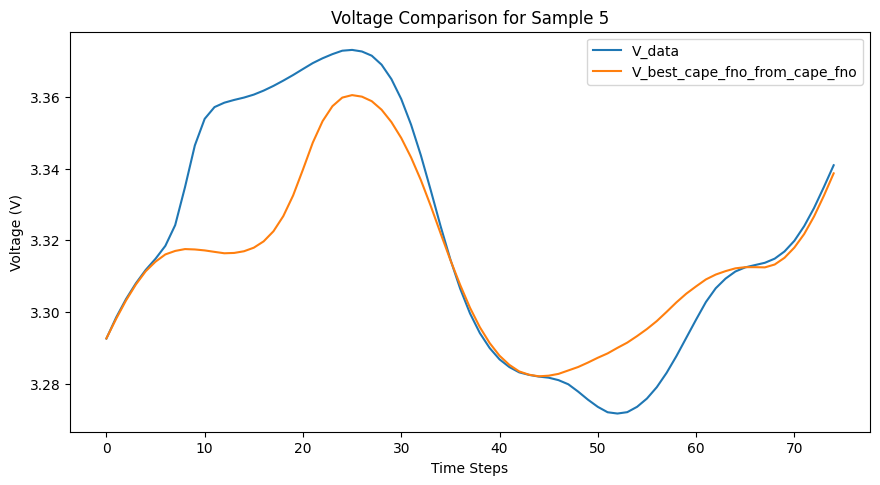

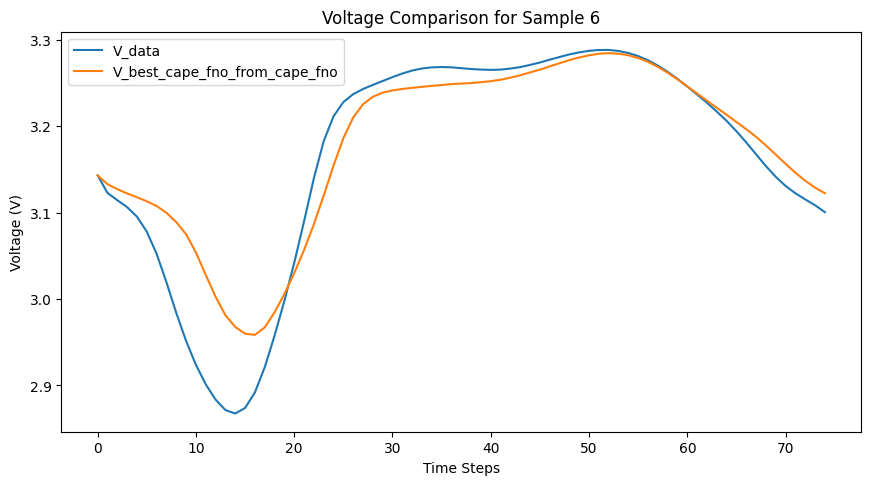

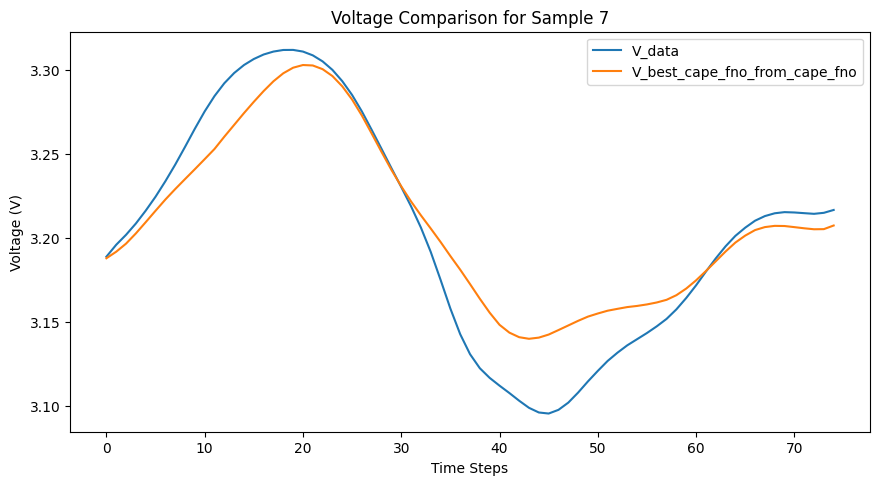

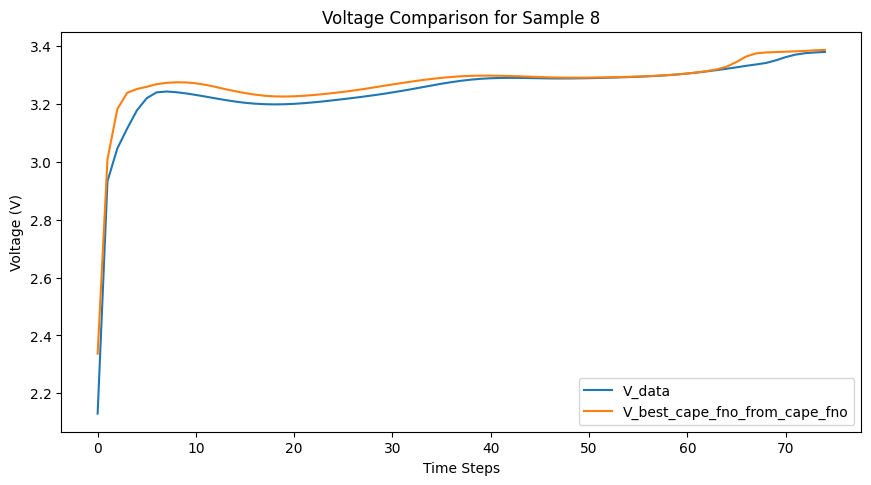

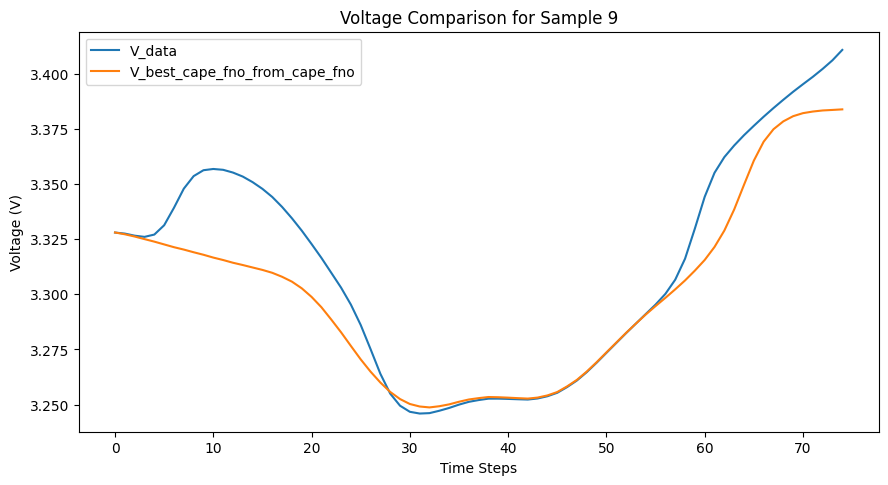

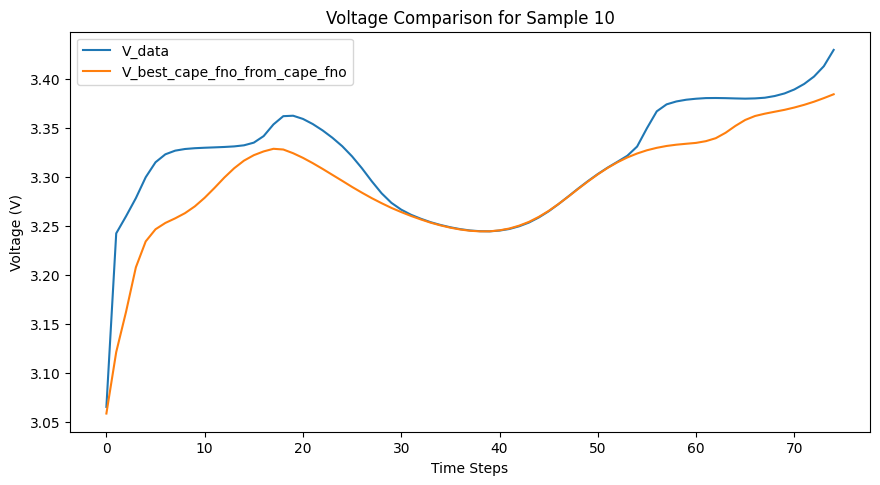

In [51]:
for lel in range(10):
    plt.figure(figsize=(10, 5))
    plt.title(f"Voltage Comparison for Sample {lel+1}")
    plt.xlabel("Time Steps")
    plt.ylabel("Voltage (V)")
    p = plt.gca().get_position()
    p.x0 = 0.1
    p.x1 = 0.9
    p.y0 = 0.1
    p.y1 = 0.9
    plt.gca().set_position(p)
    plt.plot(V_data[lel].squeeze(), label='V_data')
    plt.plot(V_best_cape_fno_from_cape_fno[lel].flatten(), label='V_best_cape_fno_from_cape_fno')
    plt.legend()

In [58]:
diff = np.abs(V_data[:10] - V_best_cape_fno_from_cape_fno)

In [60]:
diff.mean()*1000

np.float32(18.9468)

In [40]:
# V_best_cape_fno_from_cape_fno = inference_step(func_I[test_idx],
#     X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
#     normalise_diffusion(jnp.array(best_log10_Dan).reshape(-1,1)), normalise_diffusion(jnp.array(best_log10_Dca).reshape(-1,1))
# )
# print(f"Best voltage prediction: {V_best}")

In [41]:
log_Dan_true = float(D_anode[test_idx])
log_Dca_true = float(D_cathode[test_idx])

In [42]:
log_Dan_true = (log_Dan_true +1)/2*(LOG10_D_MAX-LOG10_D_MIN)+LOG10_D_MIN
log_Dca_true = (log_Dca_true +1)/2*(LOG10_D_MAX-LOG10_D_MIN)+LOG10_D_MIN

In [43]:
log_Dan_true = log_Dan_true
log_Dca_true = log_Dca_true

In [44]:
D_anode[test_idx][None, ...].shape

(1,)

In [45]:
V_test_pred = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    D_anode[test_idx][None, ...].reshape(-1,1), D_cathode[test_idx][None, ...].reshape(-1,1)
)

assert np.isclose(V_test_pred, V_data, rtol=1e-3).all(), "Test prediction does not match the data!"

AssertionError: Test prediction does not match the data!

In [ ]:
# ---- design space ----------------------------------------
dimensions_pybamm = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan_pybamm"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca_pybamm"),
]

In [ ]:
import pybamm
import numpy as np

# ▶  a baseline Li-ion model  (SPMe is fast; swap for DFN if you prefer)
pybamm_model = pybamm.lithium_ion.SPM()
pybamm_model.events = []

# ▶  time grid that matches your measured voltage trace V_true
t_eval = np.linspace(0, 3600, 75)   # dt = sample spacing [s]

# ▶  current profile: use your measured current array `func_I`
#     (shape (T,)).  Convert to an interpolant so PyBaMM can call it at any t.
current_fun = pybamm.Interpolant(t_eval, -func_I[test_idx].squeeze(), pybamm.t)

#     Tell the model to use that function instead of the built-in C-rate
params_bat["Current function [A]"] = current_fun

In [ ]:
@use_named_args(dimensions_pybamm)
def obj_voltage_pybamm(log10_Dan_pybamm, log10_Dca_pybamm):

    try:
        # --- 1.  normalise the candidate diffusivities ------------
        D_anode_candidate = 10 ** log10_Dan_pybamm
        D_cathode_candidate = 10 ** log10_Dca_pybamm

        params_bat["Negative particle diffusivity [m2.s-1]"] = D_anode_candidate
        params_bat["Positive particle diffusivity [m2.s-1]"] = D_cathode_candidate

        sim = pybamm.Simulation(pybamm_model, parameter_values=params_bat)
        sim.solve(initial_soc = soc[0], t_eval=t_eval)

        #V_pred = sim.solution["Terminal voltage [V]"](t_eval)

        c_an_surf = sim.solution["Negative particle concentration [mol.m-3]"].entries[-1,0, :].clip(EPS, 1.0 - EPS)
        c_ca_surf = sim.solution["Positive particle concentration [mol.m-3]"].entries[-1,0, :].clip(EPS, 1.0 - EPS)
        # --- 3.  voltage RMSE (you can use MAE or any other scalar) -------------
        V_pred = calc_voltage(params_bat, c_an_surf, c_ca_surf, func_I[test_idx])
        rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
        if np.isnan(rmse):
            return 1e8
        return float(rmse)

    except Exception as e:
        return float('1e8')


In [ ]:
res_pybamm = gp_minimize(
    obj_voltage_pybamm,
    dimensions=dimensions_pybamm,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan_pybamm, best_log10_Dca_pybamm = res_pybamm.x
print(f"Best log10(Dan) = {best_log10_Dan_pybamm:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca_pybamm:.3f}")
print(f"Voltage-curve RMSE = {res_pybamm.fun:.4e}")

Best log10(Dan) = -13.221
Best log10(Dca) = -12.467
Voltage-curve RMSE = 1.0812e+00


In [ ]:
params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dan
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dca

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[test_idx], t_eval=t_eval)

c_an_surf_pybamm_from_cape_fno = sim.solution["Negative particle concentration"].entries[-1, 0, :]
c_ca_surf_pybamm_from_cape_fno = sim.solution["Positive particle concentration"].entries[-1, 0, :]

# V_best_pybamm_from_cape_fno = sim.solution["Local voltage [V]"](t_eval)
V_best_pybamm_from_cape_fno = calc_voltage(params_bat, c_an_surf_pybamm_from_cape_fno, c_ca_surf_pybamm_from_cape_fno, func_I[test_idx])


params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** log_Dan_true
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** log_Dca_true

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[test_idx], t_eval=t_eval)

c_an_surf_true_pybamm = sim.solution["Negative particle concentration"].entries[-1, 0, :]
c_ca_surf_true_pybamm = sim.solution["Positive particle concentration"].entries[-1, 0, :]

# V_true_pybamm = sim.solution["Local voltage [V]"](t_eval)
V_true_pybamm = calc_voltage(params_bat, c_an_surf_true_pybamm, c_ca_surf_true_pybamm, func_I[test_idx])


params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dan_pybamm
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dca_pybamm

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[test_idx], t_eval=t_eval)
# V_best_pybamm_from_pybamm = sim.solution["Local voltage [V]"](t_eval)

c_an_surf_pybamm_from_pybamm = sim.solution["Negative particle concentration"].entries[-1, 0, :]
c_ca_surf_pybamm_from_pybamm = sim.solution["Positive particle concentration"].entries[-1, 0, :]
V_best_pybamm_from_pybamm = calc_voltage(params_bat, c_an_surf_pybamm_from_pybamm, c_ca_surf_pybamm_from_pybamm, func_I[test_idx])


In [ ]:
V_best_cape_fno_from_pybamm = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan_pybamm).reshape(-1,1)),
    normalise_diffusion(jnp.array(best_log10_Dca_pybamm).reshape(-1,1))
)

In [ ]:
import matplotlib.pyplot as plt

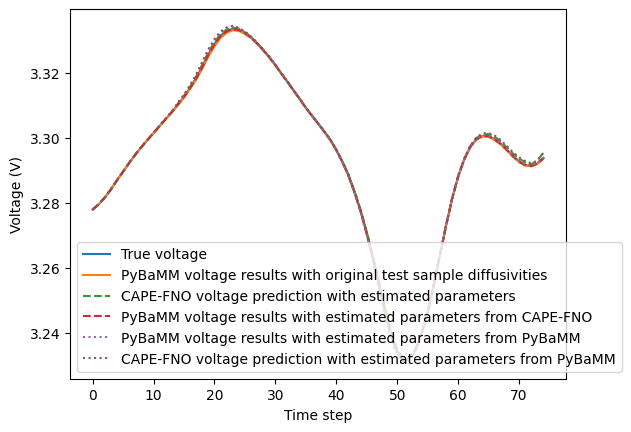

In [ ]:
plt.plot(V_data, label="True voltage")
plt.plot(V_true_pybamm, label="PyBaMM voltage results with original test sample diffusivities")

plt.plot(V_best_cape_fno_from_cape_fno.reshape(-1,1), label="CAPE-FNO voltage prediction with estimated parameters", linestyle='--')
plt.plot(V_best_pybamm_from_cape_fno.reshape(-1,1), label="PyBaMM voltage results with estimated parameters from CAPE-FNO", linestyle='--')


plt.plot(V_best_pybamm_from_pybamm.reshape(-1,1), label="PyBaMM voltage results with estimated parameters from PyBaMM", linestyle=':')
plt.plot(V_best_cape_fno_from_pybamm.reshape(-1,1), label="CAPE-FNO voltage prediction with estimated parameters from PyBaMM", linestyle=':')

plt.xlabel("Time step")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

In [ ]:
mean_error = (np.abs(best_log10_Dan - log_Dan_true) + np.abs(best_log10_Dca - log_Dca_true))/2

In [ ]:
mean_error_pybamm = (np.abs(best_log10_Dan_pybamm - log_Dan_true) + np.abs(best_log10_Dca_pybamm - log_Dca_true))/2

In [ ]:
mean_error

np.float64(0.27602968403149575)

In [ ]:
mean_error_pybamm

np.float64(0.8559948789429743)